# Retrieval-Augmented Generation (RAG)

---

# Step 1: Import Required Libraries

### What are we performing?
- Importing all the libraries required to build the RAG pipeline.
- Each library provides a specific functionality such as text preprocessing, chunking, embeddings, or similarity search.

### Why are we performing it?
- Python cannot use library functions until they are imported.
- These libraries will be used in the upcoming steps of the notebook.

---


In [15]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from sentence_transformers import SentenceTransformer
import spacy
import faiss

c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\langchain_core\utils\pydantic.py:41: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1 import BaseModel as BaseModelV1
c:\Users\LENOVO\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Step 2: Load the Dataset

### What are we performing?
- Reading the text file containing Machine Learning statements.
- Storing the complete document in the variable `data`.

### Why are we performing it?
- The RAG pipeline requires a knowledge source.
- All preprocessing and embedding generation will be performed on this data.

After this step:

```
Disk
│
└── machine_learning_2000_sentences.txt
        │
        ▼
Python Memory
┌───────────────────────────────┐
│ data = "Entire document..."   │
└───────────────────────────────┘
```

---

## Output

The variable **data** now contains the entire document as one large string.

In [2]:
data = open(r'machine_learning_2000_sentences.txt').read()
# data

# $$ Text Normalization $$

# Step 3: Convert Text to Lowercase

### What are we performing?
- Converting all characters in the document to lowercase.

### Why are we performing it?
- Ensures consistent text representation.
- Prevents words like `Machine` and `machine` from being treated differently during processing.

In [3]:
data = data.lower()

# Step 4: Remove Extra Whitespaces

### What are we performing?
- Removing multiple consecutive spaces from the document using Regular Expressions (Regex).

### Why are we performing it?
- Cleans the text.
- Creates a consistent document for the remaining preprocessing steps.

In [4]:
import re
data = re.sub(r'\s{2,}',' ',data)

# Step 5: Remove Statement Numbers

### What are we performing?
- Removing labels such as `Machine Learning Statement 1:` using Regex.

### Why are we performing it?
- These labels do not add semantic meaning.
- Prevents unnecessary text from becoming part of the embeddings.

> Syntax:
```python
data = re.sub('\d+\:', '', data)
data
```

In [ ]:
# data = re.sub(r'\d+\.','', data)
data = re.sub(r'machine learning statement \d+:','',data)
data = re.sub(r'machine learning\nstatement \d+:','',data)
data = re.sub(r'machine\nlearning statement \d+:','',data)
# data

# Step 6: Expand Contractions and Abbreviations

### What are we performing?
- Expanding contracted words into their full form.
- Example: `don't → do not`, `can't → cannot`, `ASAP → as soon as possible`.

### Why are we performing it?
- Creates a standardized text format.
- Improves text quality before further preprocessing.

In [9]:
import contractions
data = contractions.fix(data)

# Step 8: Remove Punctuation

### What are we performing?
- Importing Python's built-in punctuation characters.
- Removing all punctuation using Regular Expressions (Regex).

### Why are we performing it?
- To identify punctuation symbols that can be removed from the text.
- Keeps only meaningful words.
- Produces cleaner text for NLP preprocessing.


In [12]:
# import string
# string.punctuation

In [11]:
data = re.sub(r'[^0-9a-zA-Z\s]','', data)

# Step 9: Spell Correction

### What are we performing?
- Importing the TextBlob library for spell correction.
- Applying spell correction to the entire document.

### Why are we performing it?
- To correct spelling mistakes in the document before creating embeddings.
- Reduces spelling inconsistencies.
- Improves the quality of embeddings.

In [13]:
from textblob import TextBlob
# str(TextBlob(data).correct())

# Step 10: Load spaCy Model

### What are we performing?
- Loading the English language model from spaCy.

### Why are we performing it?
- Required for tokenization, stop-word removal, and lemmatization.

In [16]:
nlp = spacy.load('en_core_web_sm')

# Step 11: Tokenization and Lemmatization

### What are we performing?
- Splitting the text into tokens.
- Converting each word to its root (lemma).
- Removing stop words.

### Why are we performing it?
- Reduces unnecessary words.
- Converts similar word forms into a single base word.
- Produces cleaner text for embedding generation.

In [18]:
tokens = nlp(data)
updated_tokens = [token.lemma_ for token in tokens if not token.is_stop]
# updated_tokens

In [21]:
# if we want to check the word belong to which entity, .ent
# doc = nlp(data)
# for ent in doc.ents:
#     print(ent.text, ent.label_)

# Step 12: Convert Tokens Back to Text

### What are we performing?
- Joining all processed tokens into a single string.
- Removing extra spaces.

### Why are we performing it?
- Creates the final cleaned document.
- This cleaned text will be used for chunking.

In [22]:
data = ' '.join(updated_tokens).strip()
# strip: to remove extra spaces
#  we can also use it to remove special characters

# Step 13: Chunking the Document

### What are we performing?
- Preparing to split the document into smaller text chunks.

### Why are we performing it?
- LLMs cannot efficiently process very large documents at once.
- Smaller chunks improve retrieval accuracy.

In [23]:
splitter = RecursiveCharacterTextSplitter(chunk_size = 100, chunk_overlap = 20)

# Step 14: Create Text Chunks

### What are we performing?
- Splitting the cleaned document into chunks.
- Removing duplicate chunks using `set()`.

### Why are we performing it?
- Creates manageable pieces of text.
- Prevents duplicate information from being stored in the vector database.

In [27]:
chunks = splitter.split_text(data)
# chunks # type of chunks -> list of strings

In [ ]:
# docs = [Document(page_content=text, metadata={"file": "notes.txt"})]
# chunks = splitter.split_documents(data)
# chunks type of chunks -> Document

# Step 15: Generate Chunk Embeddings

### What are we performing?
- Loading the Sentence Transformer model.
- Converting every chunk into a numerical vector (embedding).

### Why are we performing it?
- Embeddings capture the semantic meaning of text.
- They allow FAISS to perform similarity search.

---
## What is SentenceTransformer?

SentenceTransformer is a class from the sentence-transformers library.

Its job is to load a pre-trained embedding model.

```
Text
   ↓
Embedding Model
   ↓
Numerical Vector
```

```python
SentenceTransformer(
    model_name_or_path="sentence-transformers/all-mpnet-base-v2"
)
```

- It downloads the model (only the first time) and stores it in the local cache.


### What is all-mpnet-base-v2?

It is a pretrained transformer model specifically trained to convert sentences into embeddings.

```Example:

"I love machine learning."

↓

[0.23, -0.81, 0.56, ..., 0.14]
```

The output vector has 768 numbers.

In [30]:
embedding_model = SentenceTransformer(
    model_name_or_path="sentence-transformers/all-miniLM-L6-V2"
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2209.22it/s]


---
### Part 1:
```python
embedding_model.encode(chunks)
```
- encode() processes each chunk through the transformer model.

Internally:

```
Chunk 1
      ↓
Transformer
      ↓
768 numbers

Chunk 2
      ↓
Transformer
      ↓
768 numbers

Chunk 3
      ↓
Transformer
      ↓
768 numbers
```

Result:

```
[
 [0.12, -0.56, ..., 0.33],
 [0.44,  0.29, ..., -0.87],
 [0.18,  0.05, ..., 0.71]
]
```

### Part 2:
```python
.astype("float32")
```
- The embeddings produced by encode() are often float64 by default. `0.1234567891234567`
- FAISS requires float32 for efficient similarity search. `0.12345679`
- This reduces memory usage by about half.

In [31]:
chunk_embeddings = embedding_model.encode(chunks).astype('float32')

# Step 16: Find Embedding Dimension

### What are we performing?
- Retrieving the size (dimension) of each embedding vector.

### Why are we performing it?
- FAISS requires the embedding dimension while creating the vector index.

```
chunks = [
    "Machine learning is AI.",
    "Python is easy.",
    "Deep learning uses neural networks.",
    "Data science is fun.",
    "RAG uses embeddings."
]
chunks
    ↆ
embeddings
[
 [0.21, -0.53, 0.84, ..., 0.17],   ← Chunk 1
 [0.41,  0.13, 0.66, ..., 0.02],   ← Chunk 2
 [0.18, -0.71, 0.44, ..., 0.91],   ← Chunk 3
 [0.32,  0.25, 0.19, ..., 0.65],   ← Chunk 4
 [0.09, -0.81, 0.57, ..., 0.38]    ← Chunk 5
]
```
```python
chunk_embeddings.shape
```
returns (5464, 384)

- 5464 → number of chunks (rows)
- 768 → numbers in each embedding (columns)
- For each 5464 chunks, 768 embedding values.

In [ ]:
# chunk_embeddings.shape (5464, 384)
dimension = chunk_embeddings.shape[1]
# chunk_embeddings.shape[1] 384

# Step 17: Normalize Embeddings

### What are we performing?
- Applying L2 normalization to all embedding vectors.

### Why are we performing it?
- Ensures all vectors have the same magnitude.
- Improves cosine similarity search in FAISS.

```
Old Vector

[5,12] # length = 13

New Vector

[5/13,
12/13]        =     [0.385,
                    0.923]
```


In [36]:
faiss.normalize_L2(chunk_embeddings)

# Step 18: Create FAISS Vector Database

### What are we performing?
- Creating a FAISS index.
- Storing all chunk embeddings in the index.

### Why are we performing it?
- Enables fast similarity search.
- Forms the knowledge base of the RAG system.

---

| Feature   | `IndexFlatL2`                  | `IndexFlatIP`                           |
| --------- | ------------------------------ | --------------------------------------- |
| Full name | Index Flat Euclidean Distance  | Index Flat Inner Product                |
| Uses      | Euclidean (L2) distance        | Inner Product (Dot Product)             |
| Goal      | Find the **smallest distance** | Find the **largest inner product**      |
| Best for  | Distance-based search          | Cosine similarity (after normalization) |
| Metric                                | Euclidean distance           | Inner Product                   |
| Better score                          | Smaller distance             | Larger score                    |
| With normalized vectors               | Equivalent to cosine ranking | Equivalent to cosine similarity |
| Common use in RAG                     | Less common                  | Most common                     |
| Recommended for Sentence Transformers | Usually no                   | Yes (after normalization)       |


---

## 1. IndexFlatL2 (Euclidean Distance)

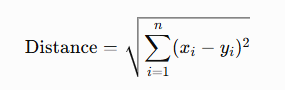

Smaller distance means the vectors are more similar.

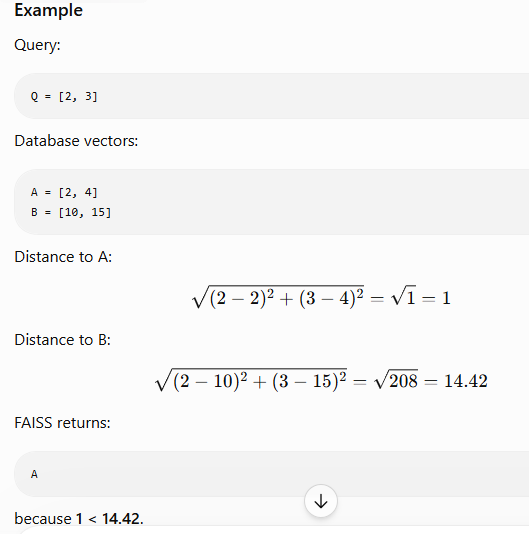

---

## 2. IndexFlatIP (Inner Product)

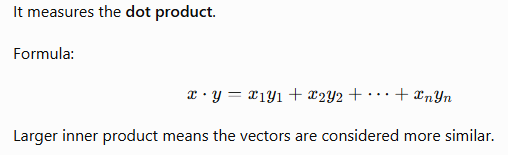

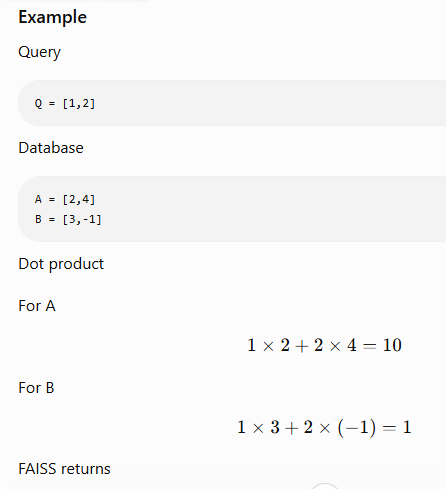

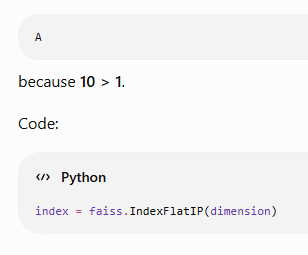

In [ ]:
index_faiss_db = faiss.IndexFlatIP(dimension) # creates an empty FAISS index
index_faiss_db.add(chunk_embeddings) # copies embedding vectors into faiss index so they become searchable

# Step 21: Define Retrieval Function

### What are we performing?
- Creating a function to retrieve the most relevant chunks for a query.

### Why are we performing it?
- Retrieves relevant context from the vector database before sending it to the LLM.

In [ ]:
# Functions to retireve the most relevant chunks from the FAISS vector database.

def r_search(query,k=2): #input query and number of nearest chunks to retrieve from FAISS
    # Convert the user's query into an embedding(vector representation)
    query_embedding = embedding_model.encode(query).astype('float32')

    #Reshape the embedding from (768,) to (1,768)
    # FAISS expects a 2D array: (number_of_queries, embedding_dimension)
    query_embedding = query_embedding.reshape(1,-1)

    # Normalize the query vector to unit length
    # Required because IndexFlatIP is being used for cosine similary
    faiss.normalize_L2(query_embedding)

    # Search the FAISS index for the k most similar vectors
    # distance -> similarity scores
    # index -> indices of the matching vectors
    distance, index = index_faiss_db.search(query_embedding, k = k)

    # Retrieve the original text chunks using the returned indices
    R_chunks = [chunks[i] for i in index[0]]

    # Combine all retrieved chunks into a single string
    R_str = ' '.join(R_chunks)

    # return the retrieved context
    return R_str



# Function to send the retrieved context to an LLM
# and recieve a structured response
def g_text(r_search):

    # Used to access environment variables
    import os
    # Used to make HTTP POST request
    import requests
    
    # Hugging Face Router API endpoint
    API_URL = "https://router.huggingface.co/v1/chat/completions"

    # Authentication header containing your Hugging Face token
    headers = {
        'Authorization' : f'Bearer {os.environ['HF_TOKEN']}',
    }

    # Helper function to send a request to the API
    def query(payload):

        # Send POST request to the Hugging Face API
        response = requests.post(
            API_URL,
            headers=headers,
            json=payload
        )

        # Convert JSON response into a python dictionary
        return response.json()

    # Prompt given to the language model
    # Retrieved chunks are inserted here

    prompt = f'''
                You're a helpful assistant.
                Assigned Task for you.
                Structure my output => {r_search}
    '''

    # Send prompt and model name to API
    response = query({
        # Chat messages
        "messages":[
            {
                "role":"user",
                # User prompt sent to the model
                "content": prompt
            }
        ],
        "model" : "deepseek-ai/DeepSeek-R1:novita" # Qwen/Qwen3-0.6B:featherless-ai
    })
#         # USE THESE MODELS
#         # DeepSeek-V3
#         # Qwen-Instruct
#         # Llama Instruct
#         # Mistral Instruct

    # Return Only generated text
    return response["choices"][0]["message"]["content"]


# User's question
user_prompt = "Explain Machine Learning."

# Remove all special characters except space
user_prompt = re.sub(r'[^0-9a-zA-Z\s]',' ',user_prompt)

# Retrieved the most relevant chunks from the FAISS vector database
r_response = r_search(user_prompt)

# send the retrieved chunks to the LLM
# The LLM generates a structured answer using the retrieved context
g_response = g_text(r_response)

# print the final response generated by the LLM
print(g_response)


<think>
We are given a task: "Structure my output => learning statement 1798 workflow emphasizing overfitting emphasize support vector machine improve carefully"

Breaking down the task:

1. We are to create a "learning statement" (likely a statement about learning or a lesson learned) with the ID 1798.
2. The workflow should emphasize "overfitting".
3. We must also emphasize "support vector machine" (SVM).
4. The goal is to "improve carefully".

Interpretation:
- We are likely discussing a machine learning workflow that involves SVM and the issue of overfitting.
- The improvement must be done carefully, which might imply using techniques to avoid overfitting while improving the model.

Structure of the output:
- Since it's a structured output, we might need to present it in a specific format. However, the task doesn't specify the exact structure, so we'll create a coherent statement that includes all the required elements.

Key points to cover:
- Mention the workflow (machine learning

In [ ]:
# Using single function
def rag(query, k=2):

    import os
    import requests

    # Step 1: Convert query to embedding
    query_embedding = embedding_model.encode(query).astype("float32")
    query_embedding = query_embedding.reshape(1, -1)
    faiss.normalize_L2(query_embedding)

    # Step 2: Search FAISS
    distance, index = index_faiss_db.search(query_embedding, k=k)

    # Step 3: Retrieve chunks
    retrieved_chunks = [chunks[i] for i in index[0]]
    retrieved_text = " ".join(retrieved_chunks)

    # Step 4: Create prompt
    prompt = f"""
    You're a helpful assistant.

    Structure the following content:

    {retrieved_text}
    """

    # Step 5: Call LLM
    response = requests.post(
        "https://router.huggingface.co/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {os.environ['HF_TOKEN']}"
        },
        json={
            "messages": [
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            "model": "Qwen/Qwen3-0.6B:featherless-ai"
        },
        timeout=90
    )

    # Step 6: Return generated answer
    return response.json()["choices"][0]["message"]["content"]

user_prompt = 'Explain Machine Learning?'
user_prompt = re.sub(r'[^0-9a-z-A-Z\s]',' ', user_prompt)

r_response = r_search(user_prompt)
g_response = g_text(r_response)
print(g_response)